# Phase 2 Linear Regression Model

This notebook trains the phase-2 linear model using the selected phase-2 feature set shared with the Random Forest notebook.

It fits two linear variants:

- **OLS Linear Regression**: plain linear regression baseline.
- **Ridge Linear Regression**: linear regression with L2 regularization, used as the primary interpretable model because even deduplicated real-estate features can remain correlated.

The target is `log(next_year_annual_median_sale_price / annual_median_sale_price)`. Metrics are reported for log growth, percent growth, and reconstructed next-year dollars.

In [1]:
from pathlib import Path
import json
import os

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'outputs' / 'phase2-models' / 'model-data').exists()
)

CACHE_DIR = PROJECT_ROOT / 'outputs' / 'cache'
os.environ.setdefault('MPLCONFIGDIR', str(CACHE_DIR / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_DIR / 'xdg'))
(CACHE_DIR / 'matplotlib').mkdir(parents=True, exist_ok=True)
(CACHE_DIR / 'xdg').mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PLOT_STYLE = {
    'figure.dpi': 120,
    'savefig.dpi': 240,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 18,
}
plt.rcParams.update(PLOT_STYLE)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
MODEL_DATA_DIR = PROJECT_ROOT / 'outputs' / 'phase2-models' / 'model-data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'phase2-models' / 'linear-regression'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

PROJECT_ROOT: /Users/charlesgao/Desktop/spring2026/stats170B/project
OUTPUT_DIR: /Users/charlesgao/Desktop/spring2026/stats170B/project/outputs/phase2-models/linear-regression


## Load Selected Model Data

In [2]:
train = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_train_2012_2022.csv', dtype={'zcta5': str}, low_memory=False)
test = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_test_2023.csv', dtype={'zcta5': str}, low_memory=False)
feature_schema = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_feature_schema.csv')
feature_config = json.loads((MODEL_DATA_DIR / 'phase2_selected_features.json').read_text())
cv_folds = pd.read_csv(MODEL_DATA_DIR / 'phase2_time_blocked_cv_folds.csv')

TARGET = 'y_next_year_median_sale_price_log_change'
TARGET_DOLLARS = 'y_next_year_median_sale_price'
CURRENT_PRICE = 'annual_median_sale_price'
FEATURES = feature_config['feature_sets']['all_selected_features']
NUMERIC_FEATURES = feature_config['preprocessing']['numeric']
CATEGORICAL_FEATURES = feature_config['preprocessing']['categorical']
BOOLEAN_FEATURES = feature_config['preprocessing']['boolean']

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Selected features: {len(FEATURES)}')
print(f'Numeric: {len(NUMERIC_FEATURES)}, categorical: {len(CATEGORICAL_FEATURES)}, boolean: {len(BOOLEAN_FEATURES)}')
print(f'Train years: {train.year.min()}-{train.year.max()}')
print(f'Test years: {sorted(test.year.unique())}')

Train shape: (12530, 59)
Test shape: (1138, 59)
Selected features: 54
Numeric: 44, categorical: 3, boolean: 7
Train years: 2012-2022
Test years: [np.int64(2023)]


## Preprocessing And Linear Model Definitions

Numeric features are median-imputed and standardized. Categorical and boolean features are imputed and one-hot encoded with a dropped reference level, which avoids exact dummy-variable duplication for OLS.

In [3]:
RIDGE_ALPHAS = np.logspace(-3, 4, 40)

def make_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
    ])
    boolean_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ('numeric', numeric_pipeline, NUMERIC_FEATURES),
            ('categorical', categorical_pipeline, CATEGORICAL_FEATURES),
            ('boolean', boolean_pipeline, BOOLEAN_FEATURES),
        ],
        remainder='drop',
        verbose_feature_names_out=True,
    )

def make_linear_pipeline(model_name: str) -> Pipeline:
    if model_name == 'ols_linear_regression':
        estimator = LinearRegression()
    elif model_name == 'ridge_linear_regression':
        estimator = RidgeCV(alphas=RIDGE_ALPHAS, scoring='neg_mean_absolute_error')
    else:
        raise ValueError(f'Unknown model_name: {model_name}')
    return Pipeline([
        ('preprocess', make_preprocessor()),
        ('model', estimator),
    ])

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_predictions(y_true_log_change, y_pred_log_change, current_price, y_true_dollars) -> dict[str, float]:
    y_true_dollars = pd.Series(y_true_dollars).astype(float)
    y_pred_dollars = pd.Series(current_price).astype(float) * np.exp(y_pred_log_change)
    y_true_growth_pct = np.expm1(y_true_log_change) * 100.0
    y_pred_growth_pct = np.expm1(y_pred_log_change) * 100.0
    return {
        'mae_log_change': mean_absolute_error(y_true_log_change, y_pred_log_change),
        'rmse_log_change': rmse(y_true_log_change, y_pred_log_change),
        'r2_log_change': r2_score(y_true_log_change, y_pred_log_change),
        'mae_growth_pct_points': mean_absolute_error(y_true_growth_pct, y_pred_growth_pct),
        'rmse_growth_pct_points': rmse(y_true_growth_pct, y_pred_growth_pct),
        'r2_growth_pct': r2_score(y_true_growth_pct, y_pred_growth_pct),
        'mae_dollars': mean_absolute_error(y_true_dollars, y_pred_dollars),
        'rmse_dollars': rmse(y_true_dollars, y_pred_dollars),
        'r2_dollars': r2_score(y_true_dollars, y_pred_dollars),
    }

def feature_group_lookup() -> dict[str, str]:
    selected = feature_schema[feature_schema['selected']].copy()
    return dict(zip(selected['feature'], selected['source_group']))

## Time-Blocked Cross Validation

In [4]:
model_names = ['ols_linear_regression', 'ridge_linear_regression']
cv_rows = []

for model_name in model_names:
    for fold in cv_folds.itertuples(index=False):
        train_fold = train[train['year'].lt(fold.validation_year)].copy()
        validation_fold = train[train['year'].eq(fold.validation_year)].copy()

        model = make_linear_pipeline(model_name)
        model.fit(train_fold[FEATURES], train_fold[TARGET])
        pred_log_change = model.predict(validation_fold[FEATURES])
        metrics = evaluate_predictions(
            validation_fold[TARGET],
            pred_log_change,
            validation_fold[CURRENT_PRICE],
            validation_fold[TARGET_DOLLARS],
        )
        estimator = model.named_steps['model']
        metrics.update({
            'model': model_name,
            'fold': fold.fold,
            'validation_year': fold.validation_year,
            'train_rows': len(train_fold),
            'validation_rows': len(validation_fold),
            'ridge_alpha': getattr(estimator, 'alpha_', np.nan),
        })
        cv_rows.append(metrics)

cv_metrics = pd.DataFrame(cv_rows)
metric_cols = ['model', 'fold', 'validation_year', 'train_rows', 'validation_rows', 'ridge_alpha', 'mae_dollars', 'rmse_dollars', 'r2_dollars', 'mae_log_change', 'rmse_log_change', 'r2_log_change', 'mae_growth_pct_points', 'rmse_growth_pct_points', 'r2_growth_pct']
cv_metrics = cv_metrics[metric_cols]
cv_metrics.to_csv(OUTPUT_DIR / 'linear_regression_cv_metrics.csv', index=False)
cv_metrics

,model,fold,validation_year,train_rows,validation_rows,ridge_alpha,mae_dollars,rmse_dollars,r2_dollars,mae_log_change,rmse_log_change,r2_log_change,mae_growth_pct_points,rmse_growth_pct_points,r2_growth_pct
0,ols_linear_regression,1,2017,5590,1146,NaN,57453.748733,132450.475960,0.937026,0.077481,0.113218,-0.341603,8.084040,11.517609,-0.401053
1,ols_linear_regression,2,2018,6736,1155,NaN,40592.046826,90392.258616,0.969649,0.056230,0.090732,-0.105990,5.842999,10.313982,-0.060804
2,ols_linear_regression,3,2019,7891,1159,NaN,86222.439392,152536.328527,0.917676,0.125563,0.156703,-0.933405,13.055492,16.011846,-1.259212
3,ols_linear_regression,4,2020,9050,1178,NaN,110448.007732,191184.540664,0.905927,0.132411,0.154026,-1.741500,14.820142,17.622333,-1.600523
4,ols_linear_regression,5,2021,10228,1160,NaN,70026.487767,112773.916399,0.968670,0.081086,0.109582,-0.428238,8.868616,11.589432,-0.442421
5,ols_linear_regression,6,2022,11388,1142,NaN,93770.253226,131165.287207,0.956672,0.110288,0.132153,-1.367914,11.335477,13.434277,-1.350612
6,ridge_linear_regression,1,2017,5590,1146,106.081836,39460.903424,112909.168699,0.954237,0.052070,0.098531,-0.016113,5.500002,9.763888,-0.006874
7,ridge_linear_regression,2,2018,6736,1155,70.170383,41743.758581,88542.430649,0.970879,0.056979,0.090799,-0.107623,5.930257,10.320114,-0.062066
8,ridge_linear_regression,3,2019,7891,1159,70.170383,77095.466293,146124.066416,0.924452,0.110477,0.145250,-0.661112,11.583377,14.784199,-0.926059
9,ridge_linear_regression,4,2020,9050,1178,242.446202,105634.136112,183581.941852,0.913260,0.125674,0.147374,-1.509828,14.138807,16.989429,-1.417082


In [5]:
cv_summary = (
    cv_metrics
    .drop(columns=['fold', 'validation_year'])
    .groupby('model')
    .agg(['mean', 'std'])
)
cv_summary.columns = ['_'.join(col).strip('_') for col in cv_summary.columns]
cv_summary = cv_summary.reset_index()
cv_summary.to_csv(OUTPUT_DIR / 'linear_regression_cv_summary.csv', index=False)
cv_summary

,model,train_rows_mean,train_rows_std,validation_rows_mean,validation_rows_std,ridge_alpha_mean,ridge_alpha_std,mae_dollars_mean,mae_dollars_std,rmse_dollars_mean,rmse_dollars_std,r2_dollars_mean,r2_dollars_std,mae_log_change_mean,mae_log_change_std,rmse_log_change_mean,rmse_log_change_std,r2_log_change_mean,r2_log_change_std,mae_growth_pct_points_mean,mae_growth_pct_points_std,rmse_growth_pct_points_mean,rmse_growth_pct_points_std,r2_growth_pct_mean,r2_growth_pct_std
0,ols_linear_regression,8480.5,2171.516682,1156.666667,12.675436,NaN,NaN,76418.830613,25452.946083,135083.801229,34552.099128,0.942603,0.026857,0.097176,0.030142,0.126069,0.026240,-0.819775,0.640997,10.334461,3.344061,13.414913,2.863380,-0.852437,0.627984
1,ridge_linear_regression,8480.5,2171.516682,1156.666667,12.675436,88.834284,82.042968,71773.761069,26846.074822,129336.737997,32870.681114,0.947944,0.023681,0.090091,0.030547,0.121151,0.024073,-0.696211,0.626894,9.635454,3.404785,12.872095,2.756311,-0.715751,0.617530


## Final Train On 2012-2022, Test On 2023

In [6]:
final_models = {}
holdout_metric_rows = []
prediction_frames = []

for model_name in model_names:
    model = make_linear_pipeline(model_name)
    model.fit(train[FEATURES], train[TARGET])
    final_models[model_name] = model
    pred_log_change = model.predict(test[FEATURES])
    metrics = evaluate_predictions(
        test[TARGET],
        pred_log_change,
        test[CURRENT_PRICE],
        test[TARGET_DOLLARS],
    )
    estimator = model.named_steps['model']
    metrics.update({
        'model': model_name,
        'train_years': '2012-2022',
        'test_year': 2023,
        'target_year': 2024,
        'ridge_alpha': getattr(estimator, 'alpha_', np.nan),
    })
    holdout_metric_rows.append(metrics)

    predictions = test[['zcta5', 'year', CURRENT_PRICE, TARGET_DOLLARS, TARGET]].copy()
    predictions['model'] = model_name
    predictions['pred_log_change_next_year_median_sale_price'] = pred_log_change
    predictions['pred_next_year_median_sale_price'] = predictions[CURRENT_PRICE] * np.exp(pred_log_change)
    predictions['absolute_error_dollars'] = (
        predictions['pred_next_year_median_sale_price'] - predictions[TARGET_DOLLARS]
    ).abs()
    predictions['error_dollars'] = (
        predictions['pred_next_year_median_sale_price'] - predictions[TARGET_DOLLARS]
    )
    prediction_frames.append(predictions)

holdout_metrics = pd.DataFrame(holdout_metric_rows)
holdout_metrics = holdout_metrics[['model', 'train_years', 'test_year', 'target_year', 'ridge_alpha', 'mae_dollars', 'rmse_dollars', 'r2_dollars', 'mae_log_change', 'rmse_log_change', 'r2_log_change', 'mae_growth_pct_points', 'rmse_growth_pct_points', 'r2_growth_pct']]
holdout_metrics.to_csv(OUTPUT_DIR / 'linear_regression_2023_holdout_metrics.csv', index=False)

holdout_predictions = pd.concat(prediction_frames, ignore_index=True)
holdout_predictions.to_csv(OUTPUT_DIR / 'linear_regression_2023_holdout_predictions.csv', index=False)
holdout_metrics

,model,train_years,test_year,target_year,ridge_alpha,mae_dollars,rmse_dollars,r2_dollars,mae_log_change,rmse_log_change,r2_log_change,mae_growth_pct_points,rmse_growth_pct_points,r2_growth_pct
0,ols_linear_regression,2012-2022,2023,2024,NaN,67244.534507,146824.994309,0.954979,0.062282,0.093857,-0.159092,6.385098,9.396331,-0.186996
1,ridge_linear_regression,2012-2022,2023,2024,13.433993,67151.232718,146840.322656,0.954970,0.062047,0.093556,-0.151660,6.362032,9.362109,-0.178365


## Coefficients

The coefficient table is based on standardized numeric features and one-hot encoded categorical/boolean features. Larger absolute coefficients indicate stronger association with next-year log price change, conditional on the other included features.

In [7]:
def original_feature_from_transformed(transformed_name: str) -> str:
    _, raw_name = transformed_name.split('__', 1)
    for feature in sorted(FEATURES, key=len, reverse=True):
        if raw_name == feature or raw_name.startswith(f'{feature}_'):
            return feature
    return raw_name

group_lookup = feature_group_lookup()
coefficient_frames = []

for model_name, model in final_models.items():
    transformed_feature_names = model.named_steps['preprocess'].get_feature_names_out()
    coefs = model.named_steps['model'].coef_
    coef_df = pd.DataFrame({
        'model': model_name,
        'transformed_feature': transformed_feature_names,
        'coefficient': coefs,
    })
    coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
    coef_df['feature'] = coef_df['transformed_feature'].map(original_feature_from_transformed)
    coef_df['source_group'] = coef_df['feature'].map(group_lookup).fillna('unknown')
    coefficient_frames.append(coef_df)

coefficients = pd.concat(coefficient_frames, ignore_index=True)
coefficients = coefficients.sort_values(['model', 'abs_coefficient'], ascending=[True, False]).reset_index(drop=True)
coefficients.to_csv(OUTPUT_DIR / 'linear_regression_coefficients_transformed.csv', index=False)

feature_coefficients = (
    coefficients.groupby(['model', 'feature', 'source_group'], as_index=False)
    .agg(
        max_abs_coefficient=('abs_coefficient', 'max'),
        sum_abs_coefficient=('abs_coefficient', 'sum'),
        coefficient_terms=('transformed_feature', 'count'),
    )
    .sort_values(['model', 'max_abs_coefficient'], ascending=[True, False])
    .reset_index(drop=True)
)
feature_coefficients.to_csv(OUTPUT_DIR / 'linear_regression_coefficients_by_feature.csv', index=False)
feature_coefficients.groupby('model').head(20)

,model,feature,source_group,max_abs_coefficient,sum_abs_coefficient,coefficient_terms
0,ols_linear_regression,parent_metro_region,listings,0.169551,0.690093,36
1,ols_linear_regression,assessment_type,school_quality,0.149683,0.195865,2
2,ols_linear_regression,total_students_tested_unreliable,school_quality,0.123849,0.123849,1
3,ols_linear_regression,school_year_complete,school_quality,0.046183,0.046183,1
4,ols_linear_regression,foreign_born_noncitizen_derived,demographics,0.035116,0.035116,1
5,ols_linear_regression,annual_sold_above_list,listings,0.018627,0.018627,1
6,ols_linear_regression,annual_avg_sale_to_list,listings,0.017283,0.017283,1
7,ols_linear_regression,annual_median_sale_price,listings,0.014899,0.014899,1
8,ols_linear_regression,annual_median_ppsf,listings,0.012916,0.012916,1
9,ols_linear_regression,minimum_wage_for_model_annual_avg,minimum_wage,0.012301,0.012301,1


## Quick Visuals

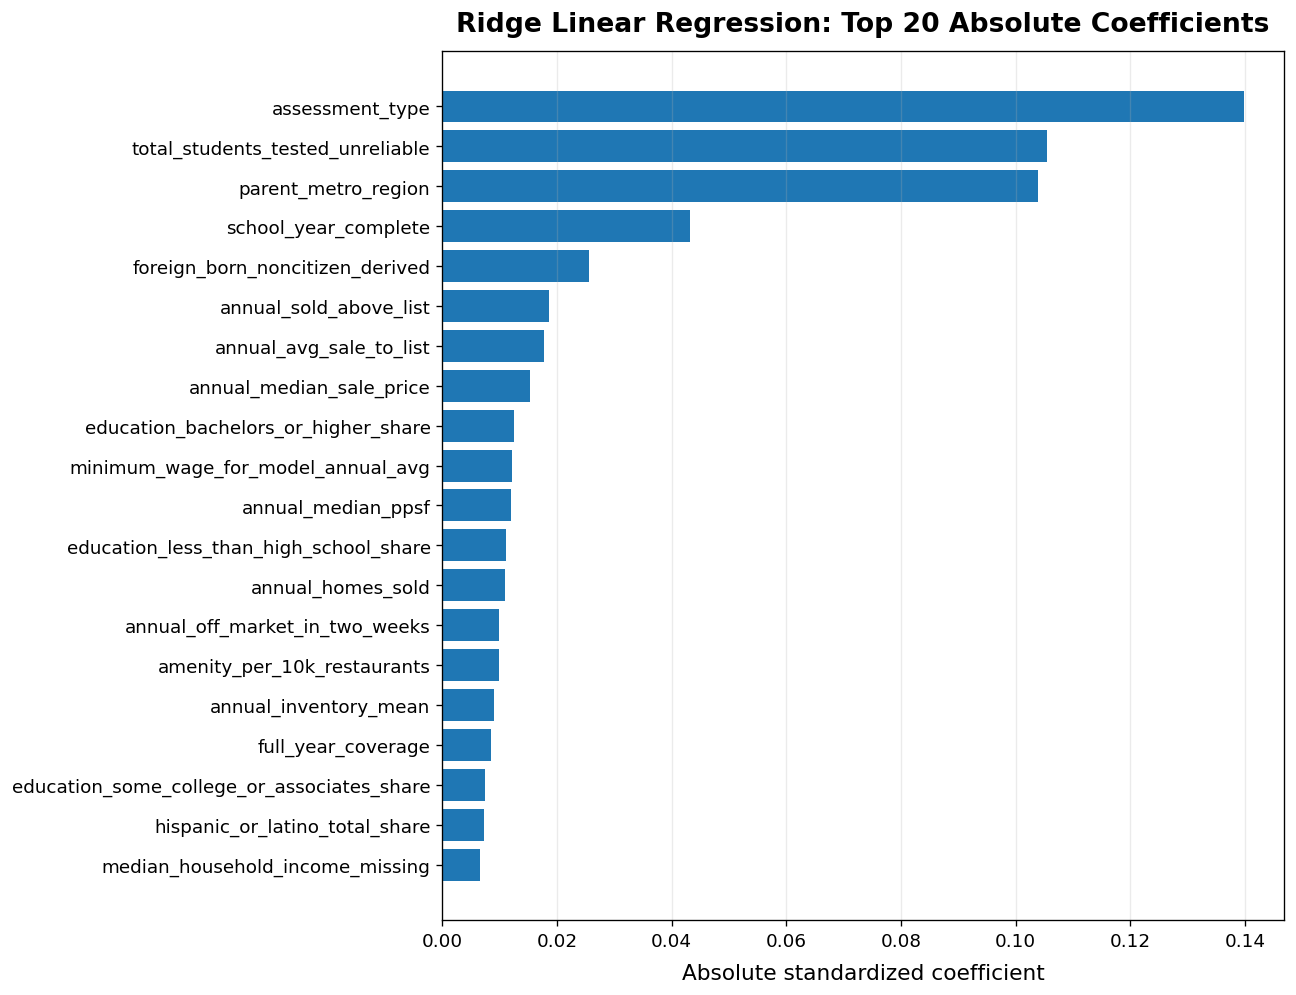

In [8]:
primary_model = 'ridge_linear_regression'
plot_df = (
    feature_coefficients[feature_coefficients['model'].eq(primary_model)]
    .head(20)
    .iloc[::-1]
)

fig, ax = plt.subplots(figsize=(11, 8.5))
ax.barh(plot_df['feature'], plot_df['max_abs_coefficient'])
ax.set_title('Ridge Linear Regression: Top 20 Absolute Coefficients', pad=12, fontweight='semibold')
ax.set_xlabel('Absolute standardized coefficient', labelpad=8)
ax.grid(axis='x', alpha=0.25)
ax.tick_params(axis='both', labelsize=11)
fig.tight_layout(pad=1.2)
fig.savefig(OUTPUT_DIR / 'ridge_top20_coefficients.png', dpi=240)
plt.show()

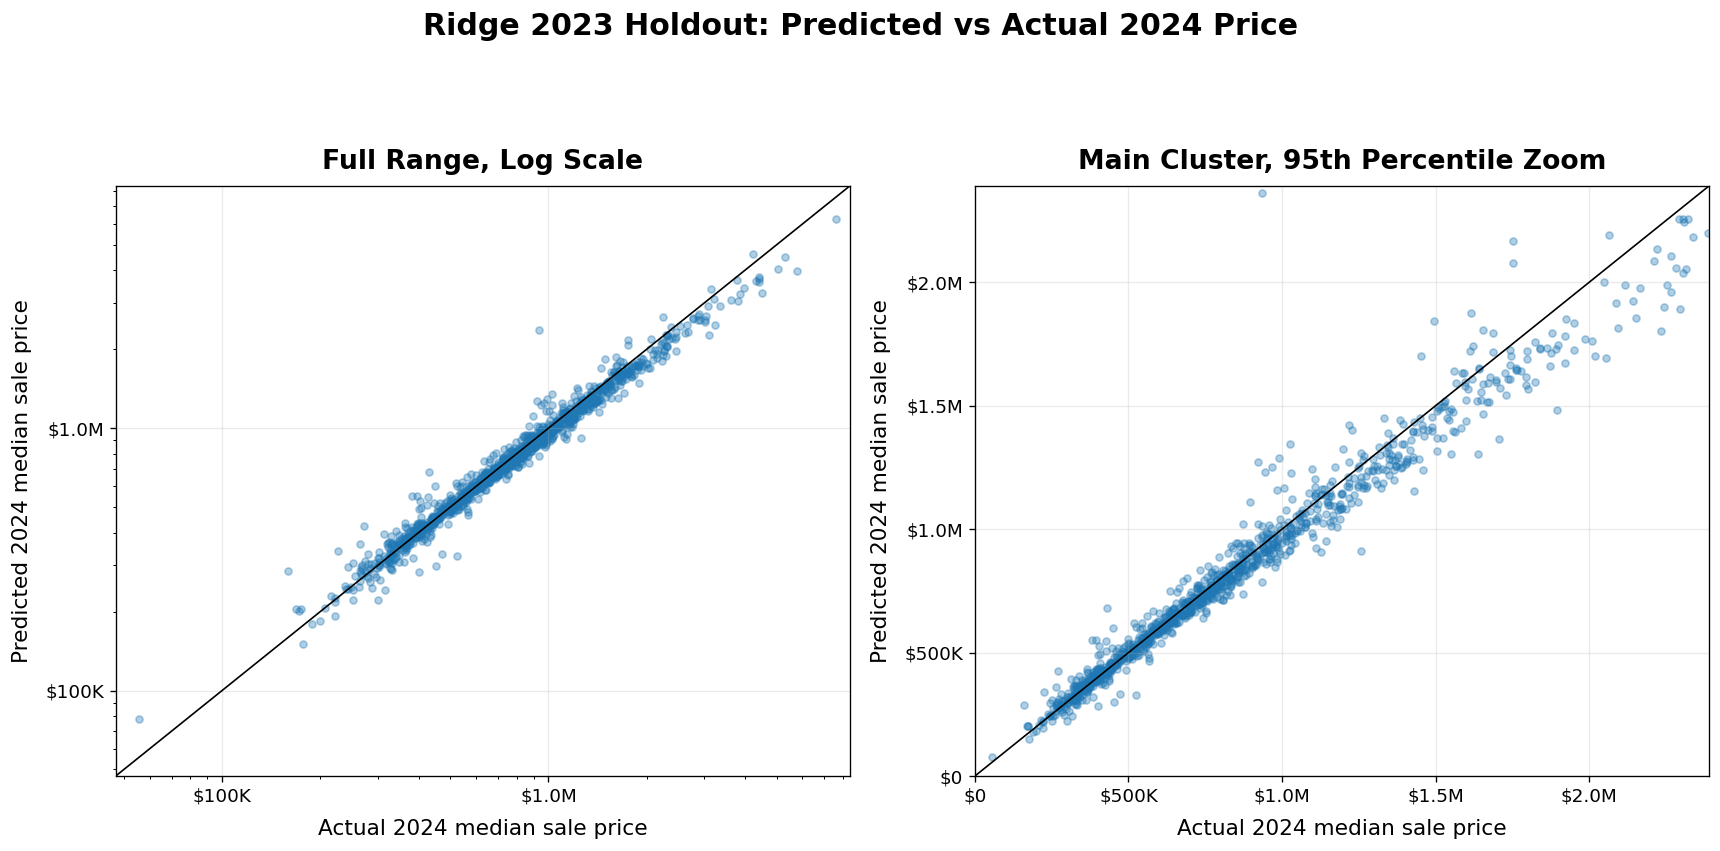

In [9]:
from matplotlib.ticker import FuncFormatter

ridge_predictions = holdout_predictions[holdout_predictions['model'].eq(primary_model)].copy()
actual_price = ridge_predictions[TARGET_DOLLARS]
predicted_price = ridge_predictions['pred_next_year_median_sale_price']

def compact_dollars(value, _):
    if value >= 1_000_000:
        return f'${value / 1_000_000:.1f}M'
    if value >= 1_000:
        return f'${value / 1_000:.0f}K'
    return f'${value:.0f}'

dollar_formatter = FuncFormatter(compact_dollars)
positive_mask = actual_price.gt(0) & predicted_price.gt(0)
full_lims = [
    min(actual_price[positive_mask].min(), predicted_price[positive_mask].min()) * 0.85,
    max(actual_price[positive_mask].max(), predicted_price[positive_mask].max()) * 1.10,
]
zoom_limit = max(actual_price.quantile(0.95), predicted_price.quantile(0.95)) * 1.10

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.8))

axes[0].scatter(actual_price, predicted_price, alpha=0.35, s=18)
axes[0].plot(full_lims, full_lims, color='black', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(full_lims)
axes[0].set_ylim(full_lims)
axes[0].set_title('Full Range, Log Scale', pad=10, fontweight='semibold')

axes[1].scatter(actual_price, predicted_price, alpha=0.35, s=18)
axes[1].plot([0, zoom_limit], [0, zoom_limit], color='black', linewidth=1)
axes[1].set_xlim(0, zoom_limit)
axes[1].set_ylim(0, zoom_limit)
axes[1].set_title('Main Cluster, 95th Percentile Zoom', pad=10, fontweight='semibold')

for ax in axes:
    ax.set_xlabel('Actual 2024 median sale price', labelpad=8)
    ax.set_ylabel('Predicted 2024 median sale price', labelpad=8)
    ax.xaxis.set_major_formatter(dollar_formatter)
    ax.yaxis.set_major_formatter(dollar_formatter)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='both', labelsize=11)

fig.suptitle('Ridge 2023 Holdout: Predicted vs Actual 2024 Price', y=1.04, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUTPUT_DIR / 'ridge_2023_predicted_vs_actual.png', dpi=240, bbox_inches='tight')
plt.show()

## Output Files

After running all cells, the key files are:

- `linear_regression_cv_metrics.csv`
- `linear_regression_cv_summary.csv`
- `linear_regression_2023_holdout_metrics.csv`
- `linear_regression_2023_holdout_predictions.csv`
- `linear_regression_coefficients_transformed.csv`
- `linear_regression_coefficients_by_feature.csv`
- `ridge_top20_coefficients.png`
- `ridge_2023_predicted_vs_actual.png`